<a href="https://colab.research.google.com/github/yunussfr/data_analysis/blob/main/DataAnalysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ogrenci_basari_verisi.csv')
if not df.empty:
   print("veri tablo haline çevirildi)")
else:
  print("malesef,olmadı")

veri tablo haline çevirildi)


In [ ]:
df.head()

,ogrenci_id,calisma_saati,uyku_saati,devam_orani,onceki_not,internet_erisim,calisma_yontemi,final_notu
0,1,4.3,6.0,NaN,65.9,Var,Bireysel,96.0
1,2,2.2,7.2,80.9,73.4,Var,Video,85.3
2,3,4.9,7.2,60.9,82.0,NaN,Grup,100.0
3,4,5.2,8.4,64.4,53.2,Yok,Karma,85.6
4,5,0.9,7.8,100.0,66.2,Var,Grup,78.0


In [ ]:
df.tail()

,ogrenci_id,calisma_saati,uyku_saati,devam_orani,onceki_not,internet_erisim,calisma_yontemi,final_notu
115,116,3.0,6.3,84.8,63.3,Var,Bireysel,72.3
116,117,4.1,4.9,84.8,82.9,Var,Video,98.5
117,118,3.8,6.8,85.2,52.0,NaN,Bireysel,87.1
118,119,6.2,5.9,71.6,68.1,Var,Bireysel,100.0
119,120,3.4,NaN,80.2,100.0,Var,Grup,100.0


In [ ]:
satir_sayisi, sutun_sayisi = df.shape

print("Satır sayısı:", satir_sayisi)
print("Sütun sayısı:", sutun_sayisi)

Satır sayısı: 120
Sütun sayısı: 8


df.shape()//iki değeri döndürür bunlar satırlar,sütünlardır

In [ ]:
print(df.columns.tolist())

['ogrenci_id', 'calisma_saati', 'uyku_saati', 'devam_orani', 'onceki_not', 'internet_erisim', 'calisma_yontemi', 'final_notu']


In [ ]:
print(df.dtypes)

ogrenci_id           int64
calisma_saati      float64
uyku_saati         float64
devam_orani        float64
onceki_not         float64
internet_erisim     object
calisma_yontemi     object
final_notu         float64
dtype: object


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ogrenci_id       120 non-null    int64  
 1   calisma_saati    115 non-null    float64
 2   uyku_saati       116 non-null    float64
 3   devam_orani      117 non-null    float64
 4   onceki_not       120 non-null    float64
 5   internet_erisim  117 non-null    object 
 6   calisma_yontemi  120 non-null    object 
 7   final_notu       120 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 7.6+ KB


In [ ]:
sayisal_sutunlar = df.select_dtypes(include="number").columns.tolist()
kategorik_sutunlar = df.select_dtypes(exclude="number").columns.tolist()

print("Sayısal sütunlar:")
print(sayisal_sutunlar)

print("\nKategorik sütunlar:")
print(kategorik_sutunlar)


Sayısal sütunlar:
['ogrenci_id', 'calisma_saati', 'uyku_saati', 'devam_orani', 'onceki_not', 'final_notu']

Kategorik sütunlar:
['internet_erisim', 'calisma_yontemi']


In [ ]:
analiz_sayisal_sutunlari = [
    sutun
    for sutun in sayisal_sutunlar
    if sutun != "ogrenci_id"
]

print(analiz_sayisal_sutunlari)

['calisma_saati', 'uyku_saati', 'devam_orani', 'onceki_not', 'final_notu']


amacımız ogrenci_id ını cıkarmak oldu cunku aslinda sayisal bir deger degildir, korelasyon ve temel istatistik sayısal degereler icin yapilir.


In [ ]:
eksik_deger_sayilari = df.isna().sum()

print(eksik_deger_sayilari)

eksik_deger_oranlari = df.isna().mean() * 100

print(eksik_deger_oranlari.round(2))

ogrenci_id         0
calisma_saati      5
uyku_saati         4
devam_orani        3
onceki_not         0
internet_erisim    3
calisma_yontemi    0
final_notu         0
dtype: int64
ogrenci_id         0.00
calisma_saati      4.17
uyku_saati         3.33
devam_orani        2.50
onceki_not         0.00
internet_erisim    2.50
calisma_yontemi    0.00
final_notu         0.00
dtype: float64


In [ ]:
tekrar_eden_satir_sayisi = df.duplicated().sum()

print("Tekrar eden satır sayısı:", tekrar_eden_satir_sayisi)

Tekrar eden satır sayısı: 0


In [ ]:
df[analiz_sayisal_sutunlari].describe().T

,count,mean,std,min,25%,50%,75%,max
calisma_saati,115.0,3.821739,1.630670,0.9,3.00,3.8,4.550,16.0
uyku_saati,116.0,6.921552,1.112835,2.0,6.20,6.8,7.425,9.9
devam_orani,117.0,81.938462,13.106591,15.0,75.10,82.9,91.000,100.0
onceki_not,120.0,67.799167,14.125158,35.3,58.40,68.5,76.975,100.0
final_notu,120.0,90.422500,8.210318,71.1,84.65,91.5,99.475,100.0


In [ ]:
for sutun in kategorik_sutunlar:
    print(f"--- {sutun} ---")
    print(df[sutun].value_counts(dropna=False))
    print()

--- internet_erisim ---
internet_erisim
Var    92
Yok    25
NaN     3
Name: count, dtype: int64

--- calisma_yontemi ---
calisma_yontemi
Bireysel    46
Karma       29
Video       23
Grup        22
Name: count, dtype: int64



.valuse_counts:uniqe degerlerin sayısını gosterir ve dropna=False ise buradaki NaN olan degerleri de saymasını saglar.

In [ ]:
for sutun in kategorik_sutunlar:
    print(f"--- {sutun} yüzdeleri ---")
    print(
        df[sutun]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
    print()


--- internet_erisim yüzdeleri ---
internet_erisim
Var    76.67
Yok    20.83
NaN     2.50
Name: proportion, dtype: float64

--- calisma_yontemi yüzdeleri ---
calisma_yontemi
Bireysel    38.33
Karma       24.17
Video       19.17
Grup        18.33
Name: proportion, dtype: float64



normalize 0-1 aralığına getiriyor unique kategorilerin sayılarını ve mul(100) ile de yüzdelik oran elde ediyoruz,round(2) ise 2 basamağa indirdiyor sayıların virgulden sonrasını

In [ ]:
def iqr_ile_aykiri_deger_bul(dataframe, sutun_adi):
    """
    Verilen sayısal sütundaki aykırı değerleri
    IQR yöntemine göre tespit eder.
    """

    seri = dataframe[sutun_adi].dropna()

    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)

    iqr = q3 - q1

    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr

    aykiri_degerler = dataframe[
        (dataframe[sutun_adi] < alt_sinir) |
        (dataframe[sutun_adi] > ust_sinir)
    ]
    print(alt_sinir,ust_sinir,aykiri_degerler)

    return alt_sinir, ust_sinir, aykiri_degerler

In [ ]:
aykiri_deger_ozeti = []

for sutun in analiz_sayisal_sutunlari:
    alt_sinir, ust_sinir, aykirilar = iqr_ile_aykiri_deger_bul(
        df,
        sutun
    )

    aykiri_deger_ozeti.append({
        "sutun": sutun,
        "alt_sinir": round(alt_sinir, 2),
        "ust_sinir": round(ust_sinir, 2),
        "aykiri_deger_sayisi": len(aykirilar)
    })

aykiri_deger_tablosu = pd.DataFrame(aykiri_deger_ozeti)

aykiri_deger_tablosu

0.6750000000000003 6.875     ogrenci_id  calisma_saati  uyku_saati  devam_orani  onceki_not  \
5            6           16.0         7.4         66.6        88.7   
30          31            7.0         6.8         73.3        35.7   

   internet_erisim calisma_yontemi  final_notu  
5              Var           Karma        85.5  
30             Var        Bireysel        82.8  
4.362499999999999 9.262500000000001      ogrenci_id  calisma_saati  uyku_saati  devam_orani  onceki_not  \
19           20            3.7         9.9         65.5        61.6   
37           38            2.5         2.0         68.7        71.2   
106         107            2.4         9.5         74.9        63.9   

    internet_erisim calisma_yontemi  final_notu  
19              Var           Video        84.2  
37              Var           Karma        98.2  
106             Var        Bireysel        87.6  
51.249999999999986 114.85000000000001     ogrenci_id  calisma_saati  uyku_saati  devam_orani  on

,sutun,alt_sinir,ust_sinir,aykiri_deger_sayisi
0,calisma_saati,0.68,6.88,2
1,uyku_saati,4.36,9.26,3
2,devam_orani,51.25,114.85,2
3,onceki_not,30.54,104.84,0
4,final_notu,62.41,121.71,0


Buradaki tablo yanlış değil, fakat sizin beklediğimiz kontrolü yapmıyor. IQR yöntemi, değerlerin mantıksal sınırlarını değil, veri içindeki istatistiksel dağılımı inceler.

In [ ]:
mantiksal_sinirlar = {
    "calisma_saati": (0, 24),
    "uyku_saati": (0, 24),
    "devam_orani": (0, 100),
    "onceki_not": (0, 100),
    "final_notu": (0, 100)
}


def mantiksal_sinir_disi_degerleri_bul(dataframe, sutun_adi, minimum, maksimum):
    """
    Belirlenen mantıksal sınırların dışında kalan
    geçersiz değerleri bulur.
    """

    gecersiz_degerler = dataframe[
        (dataframe[sutun_adi] < minimum) |
        (dataframe[sutun_adi] > maksimum)
    ]

    return gecersiz_degerler

mantiksal_hata_ozeti = []

for sutun, sinirlar in mantiksal_sinirlar.items():
    minimum, maksimum = sinirlar

    gecersizler = mantiksal_sinir_disi_degerleri_bul(
        df,
        sutun,
        minimum,
        maksimum
    )

    mantiksal_hata_ozeti.append({
        "sutun": sutun,
        "minimum_gecerli": minimum,
        "maksimum_gecerli": maksimum,
        "gecersiz_deger_sayisi": len(gecersizler)
    })

mantiksal_hata_tablosu = pd.DataFrame(mantiksal_hata_ozeti)

mantiksal_hata_tablosu

,sutun,minimum_gecerli,maksimum_gecerli,gecersiz_deger_sayisi
0,calisma_saati,0,24,0
1,uyku_saati,0,24,0
2,devam_orani,0,100,0
3,onceki_not,0,100,0
4,final_notu,0,100,0


In [ ]:
#mantıksal sınır kontrolu ile birlestirilmis hali
def veri_kalitesi_kontrolu(dataframe, sutun_adi, minimum, maksimum):
    seri = dataframe[sutun_adi].dropna()

    # Mantıksal olarak geçersiz değerler
    mantiksal_gecersiz_maskesi = (
        (dataframe[sutun_adi] < minimum) |
        (dataframe[sutun_adi] > maksimum)
    )

    # IQR sınırlarının hesaplanması
    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)
    iqr = q3 - q1

    iqr_alt_sinir = q1 - 1.5 * iqr
    iqr_ust_sinir = q3 + 1.5 * iqr

    iqr_aykiri_maskesi = (
        (dataframe[sutun_adi] < iqr_alt_sinir) |
        (dataframe[sutun_adi] > iqr_ust_sinir)
    )

    # Mantıksal olarak geçersiz olanları tekrar
    # istatistiksel aykırı saymıyoruz
    sadece_istatistiksel_aykiri = (
        iqr_aykiri_maskesi &
        ~mantiksal_gecersiz_maskesi
    )

    return {
        "sutun": sutun_adi,
        "gecerli_minimum": minimum,
        "gecerli_maksimum": maksimum,
        "iqr_alt_sinir": round(iqr_alt_sinir, 2),
        "iqr_ust_sinir": round(iqr_ust_sinir, 2),
        "mantiksal_gecersiz_sayisi": int(
            mantiksal_gecersiz_maskesi.sum()
        ),
        "istatistiksel_aykiri_sayisi": int(
            sadece_istatistiksel_aykiri.sum()
        )
    }

In [ ]:
kontrol_sonuclari = []

for sutun, sinirlar in mantiksal_sinirlar.items():
    minimum, maksimum = sinirlar

    sonuc = veri_kalitesi_kontrolu(
        df,
        sutun,
        minimum,
        maksimum
    )

    kontrol_sonuclari.append(sonuc)

kontrol_tablosu = pd.DataFrame(kontrol_sonuclari)

kontrol_tablosu

,sutun,gecerli_minimum,gecerli_maksimum,iqr_alt_sinir,iqr_ust_sinir,mantiksal_gecersiz_sayisi,istatistiksel_aykiri_sayisi
0,calisma_saati,0,24,0.68,6.88,0,2
1,uyku_saati,0,24,4.36,9.26,0,3
2,devam_orani,0,100,51.25,114.85,0,2
3,onceki_not,0,100,30.54,104.84,0,0
4,final_notu,0,100,62.41,121.71,0,0


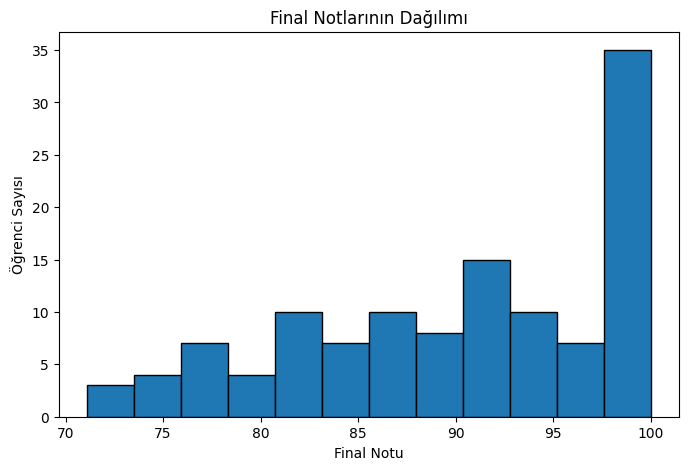

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["final_notu"].dropna(),
    bins=12,
    edgecolor="black"
)

plt.title("Final Notlarının Dağılımı")
plt.xlabel("Final Notu")
plt.ylabel("Öğrenci Sayısı")

plt.show()

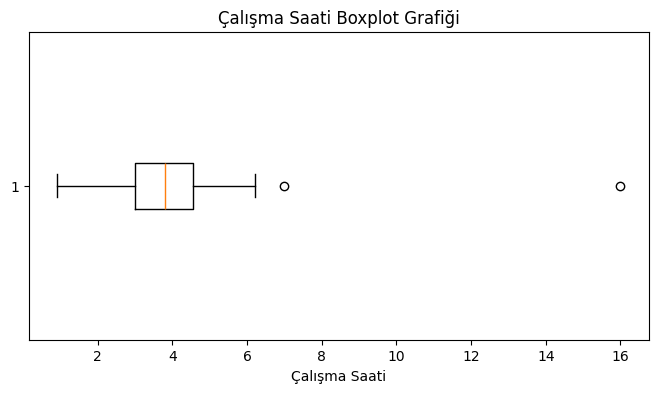

In [ ]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df["calisma_saati"].dropna(),
    vert=False
)

plt.title("Çalışma Saati Boxplot Grafiği")
plt.xlabel("Çalışma Saati")

plt.show()

boxplot grafiği bize aykırı değerleri gösterir tabi ki bunlar IQR a göre hesaplanmıştır,Gerçekliği bir uzman tarafından teşhis edilebilir.Sol bıyık çizgisi bizim aykırı değerlerin minimumudur ve oradan diktörgen başlangıcna gidene kadar verinin %25 lik kısmı gözükür ondan sonra  ise medyana kadar (burada medyan turuncu çizgi oluyor) %50 lik kısım ve ondan sonra ise bu şekilde diğer tarafta %100 e kadar devam etmektedir.

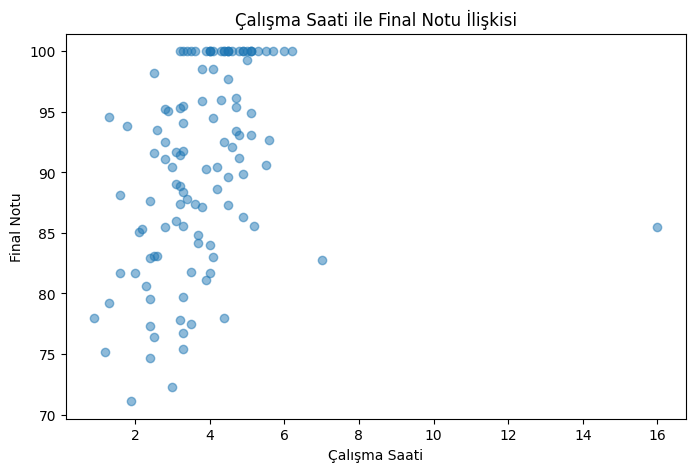

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["calisma_saati"],
    df["final_notu"],
    alpha=0.5
)

plt.title("Çalışma Saati ile Final Notu İlişkisi")
plt.xlabel("Çalışma Saati")
plt.ylabel("Final Notu")

plt.show()

yukarıda da olduğu gibi örnek gösterim olarak çalışma saati seçilmiş ve bununla beraber burda ek olarak ise final notu seçilmiştir ve bunalr arasındaki ilişki gözükmeketedir.

In [ ]:
yonteme_gore_not_ortalamasi = (
    df.groupby("calisma_yontemi")["final_notu"]
    .mean()
    .sort_values(ascending=False)
)

yonteme_gore_not_ortalamasi

,final_notu
calisma_yontemi,
Bireysel,91.743478
Karma,91.072414
Grup,88.868182
Video,88.447826


kategörik degisken olan calısma yontemini burada sınıflandırdırdık o grubtaki öğrencileri ve onların ortalama sınav notlarını inceledik

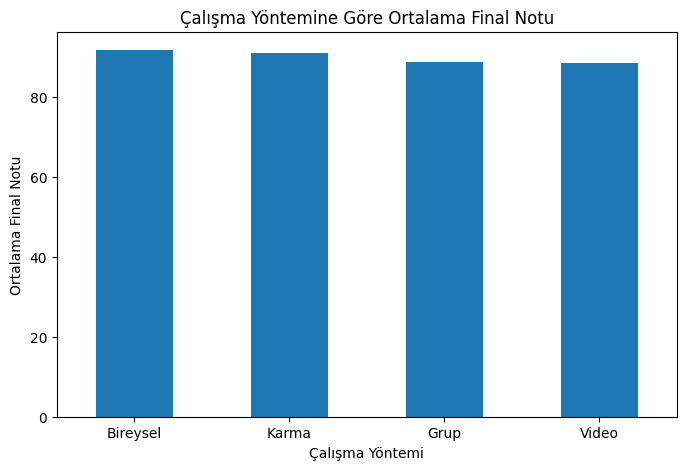

In [ ]:
plt.figure(figsize=(8, 5))

yonteme_gore_not_ortalamasi.plot(kind="bar")

plt.title("Çalışma Yöntemine Göre Ortalama Final Notu")
plt.xlabel("Çalışma Yöntemi")
plt.ylabel("Ortalama Final Notu")
plt.xticks(rotation=0)

plt.show()

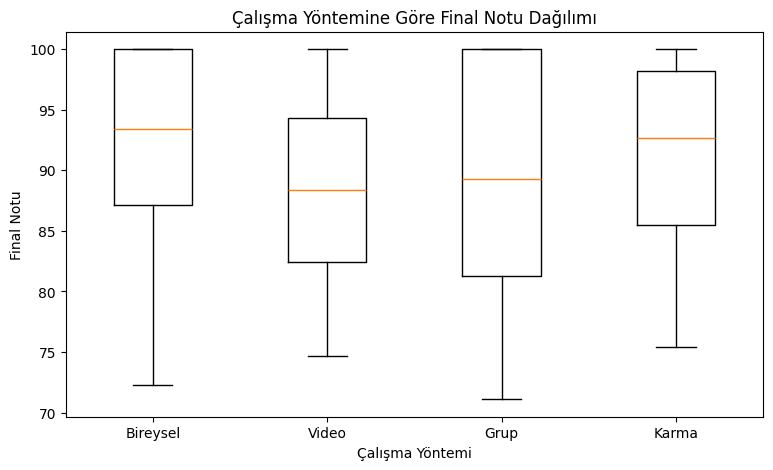

In [ ]:
gruplar = []

grup_isimleri = []

for yontem in df["calisma_yontemi"].dropna().unique():
    grup_verisi = df.loc[
        df["calisma_yontemi"] == yontem,
        "final_notu"
    ].dropna()

    gruplar.append(grup_verisi)
    grup_isimleri.append(yontem)

plt.figure(figsize=(9, 5))

plt.boxplot(
    gruplar,
    tick_labels=grup_isimleri
)

plt.title("Çalışma Yöntemine Göre Final Notu Dağılımı")
plt.xlabel("Çalışma Yöntemi")
plt.ylabel("Final Notu")

plt.show()

In [ ]:
korelasyon_sutunlari = [
    "calisma_saati",
    "uyku_saati",
    "devam_orani",
    "onceki_not",
    "final_notu"
]

korelasyon_matrisi = df[korelasyon_sutunlari].corr()

korelasyon_matrisi

,calisma_saati,uyku_saati,devam_orani,onceki_not,final_notu
calisma_saati,1.000000,-0.000713,-0.211507,0.023577,0.319252
uyku_saati,-0.000713,1.000000,0.035583,-0.046512,-0.014973
devam_orani,-0.211507,0.035583,1.000000,-0.110621,-0.102863
onceki_not,0.023577,-0.046512,-0.110621,1.000000,0.389815
final_notu,0.319252,-0.014973,-0.102863,0.389815,1.000000


korelasyon bir değerin başka bir değer ile beraber hareketini inceler onda bir aktivite olduğunda bunun diğerinde şekil bulmasını gösterir

In [ ]:
final_notu_korelasyonlari = (
    korelasyon_matrisi["final_notu"]
    .drop("final_notu")
    .sort_values(ascending=False)
)

final_notu_korelasyonlari

,final_notu
onceki_not,0.389815
calisma_saati,0.319252
uyku_saati,-0.014973
devam_orani,-0.102863


belirli bir değikene göre sıralamasının yüksekten düşüğe doğru gösterimi

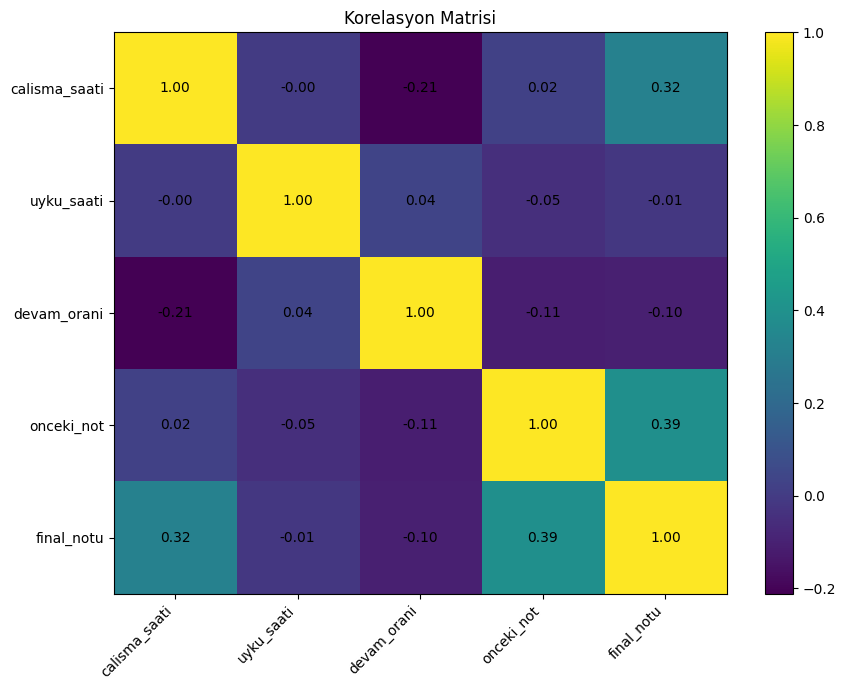

In [ ]:
plt.figure(figsize=(9, 7))

goruntu = plt.imshow(
    korelasyon_matrisi,
    aspect="auto"
)

plt.colorbar(goruntu)

plt.xticks(
    range(len(korelasyon_matrisi.columns)),
    korelasyon_matrisi.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(korelasyon_matrisi.index)),
    korelasyon_matrisi.index
)

for satir in range(len(korelasyon_matrisi.index)):
    for sutun in range(len(korelasyon_matrisi.columns)):
        deger = korelasyon_matrisi.iloc[satir, sutun]

        plt.text(
            sutun,
            satir,
            f"{deger:.2f}",
            ha="center",
            va="center"
        )

plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [ ]:
internet_ozeti = (
    df.groupby("internet_erisim")["final_notu"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

internet_ozeti

,count,mean,median,std
internet_erisim,,,,
Var,92,91.07,92.6,8.14
Yok,25,87.86,86.0,8.37


# Veri Analizi Sonucu

Veri seti toplam 120 satır ve 8 sütundan oluşmaktadır.

Eksik değerler calisma_saati,uyku_saati,devam_oranı,internet_erisimi sütunlarında bulunmaktadır. En fazla eksik değer
calisma_saati sütununda görülmüştür.

Sayısal değişkenler incelendiğinde calisma_saati sütununda sıra dışı değerler
tespit edilmiştir. Örneğin 16 değeri normal dağılımdan belirgin
biçimde uzaktadır.

Final notu ile en yüksek pozitif korelasyona sahip değişken onceki_not olarak
belirlenmiştir. Korelasyon katsayısı yaklaşık 0.4 değerindedir.

Çalışma saati ve final notu scatter grafiği, iki değişken arasında pozitif
yönlü bir ilişki olduğunu göstermektedir.

Çalışma yöntemlerine göre final notları incelendiğinde bireysel_calisma yöntemi en
yüksek ortalamaya sahip görünmektedir. Ancak yalnızca bu gözleme
dayanarak yöntemin başarıya neden olduğu söylenemez.